100%|██████████| 10/10 [00:05<00:00,  1.71it/s]


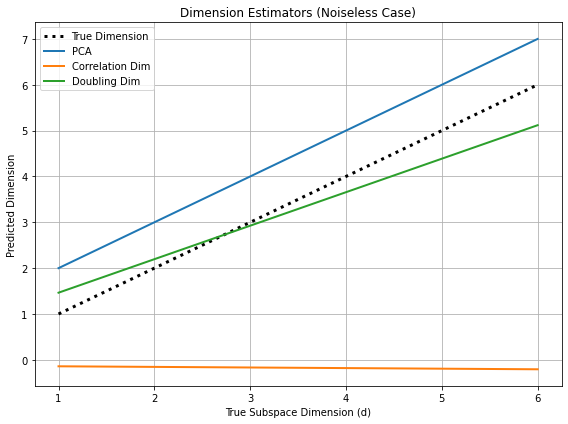

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from functions import synthetic_subspace, correlation_dim, doubling_dim, pca_elbow_estimate

# Sweep over true subspace dimensions
D = 1000
n = 2000
noise_scale = 0.0
d_vals = list(range(1, 10, 5))
pca_vals, corr_vals, dbl_vals = [], [], []

for d in d_vals:
    X = synthetic_subspace(D, d, n, signal_scale=1.0, noise_scale=noise_scale)
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    X_sample = X[:300]  # sample a subset for estimation
    pca_vals.append(pca_elbow_estimate(X_sample))
    corr_vals.append(correlation_dim(X_sample, num_trials=3, sample_size=100))
    dbl_vals.append(doubling_dim(X_sample, num_trials=3, sample_size=10))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(d_vals, d_vals, label="True Dimension", linewidth=3, color="black", linestyle=':')
plt.plot(d_vals, pca_vals, label="PCA", linewidth=2)
plt.plot(d_vals, corr_vals, label="Correlation Dim", linewidth=2)
plt.plot(d_vals, dbl_vals, label="Doubling Dim", linewidth=2)
plt.xlabel("True Subspace Dimension (d)")
plt.ylabel("Predicted Dimension")
plt.title("Dimension Estimators (Noiseless Case)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


13.252745726098892

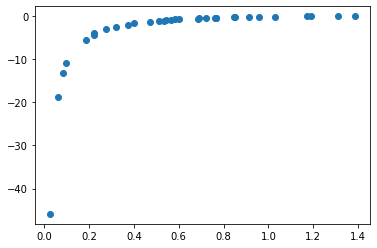

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from functions import *#synthetic_subspace, correlation_dim, doubling_dim, pca_elbow_estimate
import math
import random 
from tqdm import tqdm
from scipy.spatial.distance import pdist
from scipy.spatial import KDTree
import numpy as np
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


def correlation_dim2(X, num_trials = 10):
    
    distances = pdist(X)#np.random.choice(pdist(X), size=num_trials, replace=False)
    distances = [r for r in distances if math.log(r) > 0]
    x = [math.log(r) for r in distances]
    y = [correlation_dim_fixed_r2(r, X) for r in distances] 
    
    plt.scatter(x,y)

    m, b = np.polyfit(x, y, deg=1)
    return m


X = synthetic_subspace(D=50, d=2, n=10, signal_scale=1.0, noise_scale=0)
#correlation_dim(X, num_trials=10, sample_size=100)
correlation_dim2(X, num_trials=45)


(array([6., 4., 8., 7., 4., 6., 2., 2., 3., 3.]),
 array([0.31306051, 0.5543111 , 0.79556169, 1.03681228, 1.27806287,
        1.51931345, 1.76056404, 2.00181463, 2.24306522, 2.48431581,
        2.72556639]),
 <BarContainer object of 10 artists>)

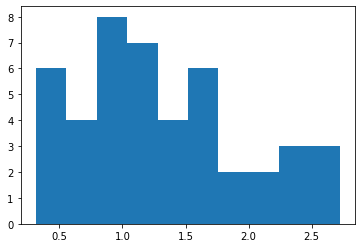

In [34]:
plt.hist(pdist(X))

100%|██████████| 5/5 [00:16<00:00,  3.23s/it]


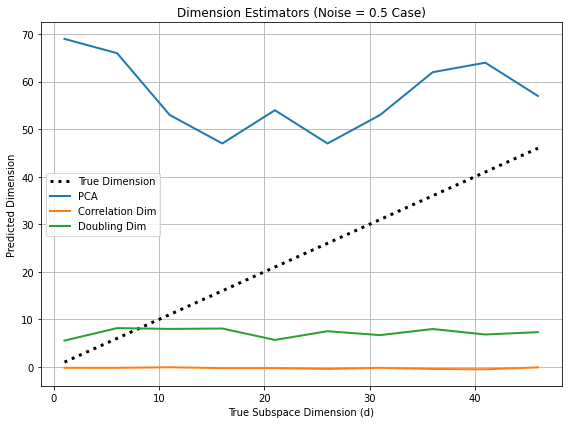

In [ ]:
# Sweep over true subspace dimensions
D = 1000
n = 2000
noise_scale = 0.001
d_vals = list(range(1, 51, 5))
pca_vals, corr_vals, dbl_vals = [], [], []

for d in d_vals:
    X = synthetic_subspace(D, d, n, signal_scale=1.0, noise_scale=noise_scale)
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    X_sample = X[:300]  # sample a subset for estimation
    pca_vals.append(pca_elbow_estimate(X_sample))
    corr_vals.append(correlation_dim(X_sample, num_trials=3, sample_size=100))
    dbl_vals.append(doubling_dim(X_sample, num_trials=1, sample_size=5))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(d_vals, d_vals, label="True Dimension", linewidth=3, color="black", linestyle=':')
plt.plot(d_vals, pca_vals, label="PCA", linewidth=2)
plt.plot(d_vals, corr_vals, label="Correlation Dim", linewidth=2)
plt.plot(d_vals, dbl_vals, label="Doubling Dim", linewidth=2)
plt.xlabel("True Subspace Dimension (d)")
plt.ylabel("Predicted Dimension")
plt.title("Dimension Estimators (Noise = 0.5 Case)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()